# %% [markdown]
# # 01 — Direct Earth → Jupiter Transfer (Baseline)
# 
# Establishes the baseline case: a direct Hohmann-class transfer from Earth to Jupiter
# with no gravity assists. This demonstrates that direct transfer requires prohibitively
# high C3, motivating the need for gravity assist trajectories.
#
# **Method:** Lambert solver (pykep) over a grid of launch dates and times of flight.
# Uses JPL low-precision analytical ephemerides for planet positions.

In [1]:
# %% Cell 1 — Imports and setup
import numpy as np
import matplotlib.pyplot as plt
import pykep as pk

# Planet objects (JPL low-precision analytical ephemerides)
earth = pk.planet.jpl_lp('earth')
jupiter = pk.planet.jpl_lp('jupiter')

# Print confirmation
print(f"pykep version: {pk.__version__}")
print(f"Earth: {earth}")
print(f"Jupiter: {jupiter}")

pykep version: {'major': 2, 'minor': 6}
Earth: Planet Name: earth
Own gravity parameter: 398600441800000
Central body gravity parameter: 1.32712440018e+20
Planet radius: 6378000
Planet safe radius: 7015800.0000000009
Ephemerides type: JPL low-precision

Jupiter: Planet Name: jupiter
Own gravity parameter: 1.26686534e+17
Central body gravity parameter: 1.32712440018e+20
Planet radius: 71492000
Planet safe radius: 643428000
Ephemerides type: JPL low-precision



In [2]:
# %% Cell 2 — Define porkchop grid
# Launch window: 2030-01-01 to 2038-01-01
# TOF range: 1.0 to 5.0 years (Hohmann is ~2.73 yr)

launch_start = pk.epoch_from_string('2030-01-01 00:00:00')
launch_end   = pk.epoch_from_string('2038-01-01 00:00:00')

t0_mjd2000_start = launch_start.mjd2000
t0_mjd2000_end   = launch_end.mjd2000

tof_min_days = 1.0 * 365.25
tof_max_days = 5.0 * 365.25

# Grid resolution
n_launch = 300   # launch date steps
n_tof    = 200   # TOF steps

launch_dates = np.linspace(t0_mjd2000_start, t0_mjd2000_end, n_launch)
tofs         = np.linspace(tof_min_days, tof_max_days, n_tof)

print(f"Grid: {n_launch} x {n_tof} = {n_launch * n_tof:,} Lambert problems")
print(f"Launch window: {pk.epoch(launch_dates[0], 'mjd2000')} to {pk.epoch(launch_dates[-1], 'mjd2000')}")
print(f"TOF range: {tof_min_days/365.25:.1f} to {tof_max_days/365.25:.1f} years")

Grid: 300 x 200 = 60,000 Lambert problems
Launch window: 2030-Jan-01 00:00:00 to 2038-Jan-01 00:00:00
TOF range: 1.0 to 5.0 years


In [3]:
# %% Cell 3 — Compute porkchop data
# For each (launch_date, TOF), solve Lambert and extract:
#   - C3 at Earth departure (km²/s²)
#   - V_inf at Jupiter arrival (km/s)

C3_grid    = np.full((n_tof, n_launch), np.nan)
vinf_arr_grid = np.full((n_tof, n_launch), np.nan)

for i, t0 in enumerate(launch_dates):
    ep_depart = pk.epoch(t0, 'mjd2000')
    r_earth, v_earth = earth.eph(ep_depart)
    
    for j, tof in enumerate(tofs):
        ep_arrive = pk.epoch(t0 + tof, 'mjd2000')
        r_jup, v_jup = jupiter.eph(ep_arrive)
        
        try:
            # Solve Lambert (prograde, single revolution)
            tof_seconds = tof * pk.DAY2SEC
            lamb = pk.lambert_problem(r_earth, r_jup, tof_seconds, pk.MU_SUN, False)
            
            # First (shortest) solution
            v_sc_depart = np.array(lamb.get_v1()[0])
            v_sc_arrive = np.array(lamb.get_v2()[0])
            
            # V_infinity vectors
            vinf_dep = v_sc_depart - np.array(v_earth)
            vinf_arr = v_sc_arrive - np.array(v_jup)
            
            # C3 in km²/s² (pykep uses m/s, so convert)
            vinf_dep_kms = np.linalg.norm(vinf_dep) / 1000.0
            vinf_arr_kms = np.linalg.norm(vinf_arr) / 1000.0
            
            C3 = vinf_dep_kms ** 2
            
            C3_grid[j, i] = C3
            vinf_arr_grid[j, i] = vinf_arr_kms
            
        except Exception:
            # Lambert solver can fail for extreme geometries
            pass

    # Progress indicator (every 10%)
    if (i + 1) % (n_launch // 10) == 0:
        print(f"  {100*(i+1)//n_launch}% complete")

print("Done.")

  10% complete
  20% complete
  30% complete
  40% complete
  50% complete
  60% complete
  70% complete
  80% complete
  90% complete
  100% complete
Done.


In [4]:
# %% Cell 4 — Find minimum C3 point
# Mask invalid entries
valid = ~np.isnan(C3_grid)

# Global minimum C3
idx_flat = np.nanargmin(C3_grid)
j_best, i_best = np.unravel_index(idx_flat, C3_grid.shape)

best_c3       = C3_grid[j_best, i_best]
best_vinf_dep = np.sqrt(best_c3)  # km/s
best_vinf_arr = vinf_arr_grid[j_best, i_best]
best_launch   = launch_dates[i_best]
best_tof      = tofs[j_best]
best_arrival  = best_launch + best_tof

launch_ep  = pk.epoch(best_launch, 'mjd2000')
arrive_ep  = pk.epoch(best_arrival, 'mjd2000')

# ΔV from 200 km LEO to departure hyperbola (Oberth effect)
mu_earth = pk.MU_EARTH  # m³/s²
r_leo = (6371 + 200) * 1000  # meters
v_circ_leo = np.sqrt(mu_earth / r_leo) / 1000  # km/s
v_escape_leo = np.sqrt(2 * mu_earth / r_leo) / 1000  # km/s
v_hyp_leo = np.sqrt(v_escape_leo**2 + best_vinf_dep**2)  # km/s
dv_from_leo = v_hyp_leo - v_circ_leo  # km/s

print("=" * 55)
print("  DIRECT TRANSFER — MINIMUM C3 SOLUTION")
print("=" * 55)
print(f"  Launch date:      {launch_ep}")
print(f"  Arrival date:     {arrive_ep}")
print(f"  Time of flight:   {best_tof:.1f} days ({best_tof/365.25:.2f} years)")
print(f"  C3 (departure):   {best_c3:.2f} km²/s²")
print(f"  V∞ (departure):   {best_vinf_dep:.3f} km/s")
print(f"  V∞ (Jupiter arr): {best_vinf_arr:.3f} km/s")
print(f"  ΔV from 200km LEO: {dv_from_leo:.3f} km/s")
print("=" * 55)

  DIRECT TRANSFER — MINIMUM C3 SOLUTION
  Launch date:      2030-Jan-20 13:05:01.003345
  Arrival date:     2032-May-04 15:56:52.561133
  Time of flight:   835.1 days (2.29 years)
  C3 (departure):   76.73 km²/s²
  V∞ (departure):   8.760 km/s
  V∞ (Jupiter arr): 6.406 km/s
  ΔV from 200km LEO: 6.285 km/s


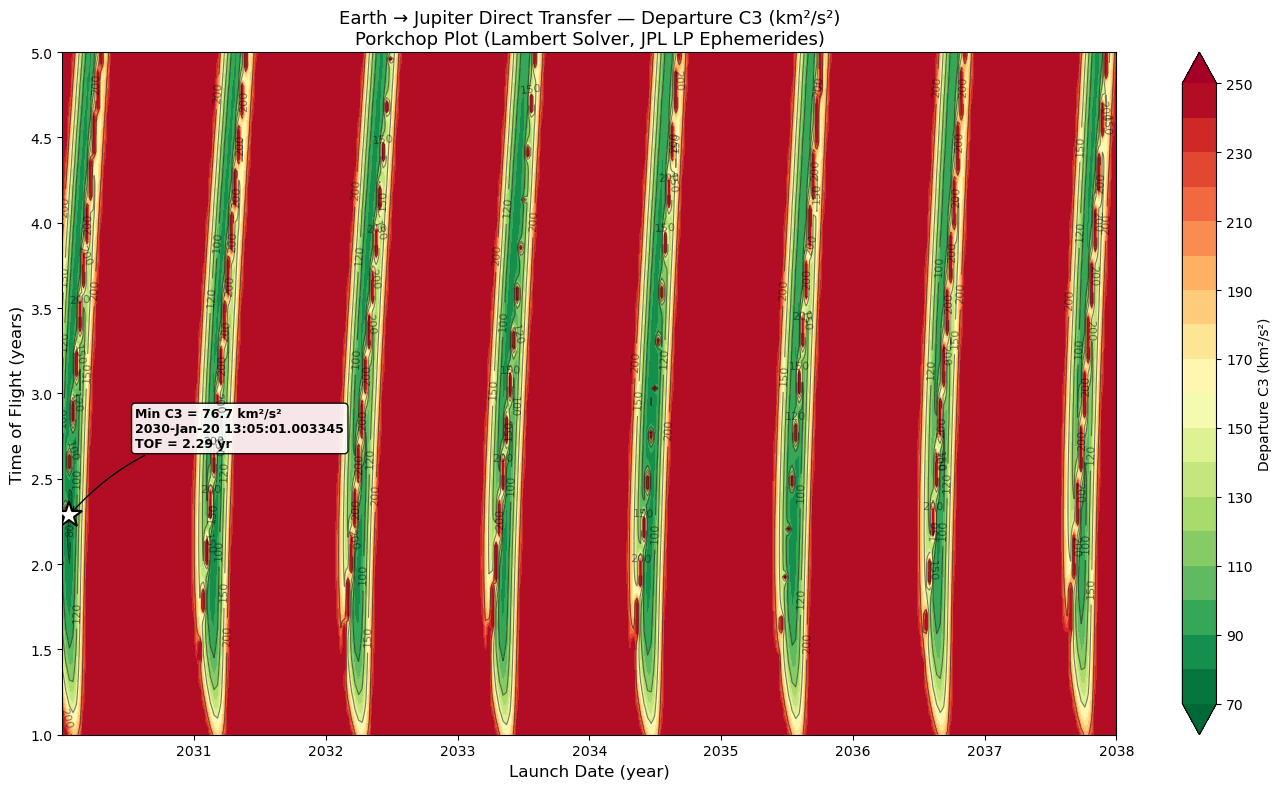

Saved: output/01_porkchop_c3.png


In [5]:
# %% Cell 5 — Porkchop plot
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Convert axes to convenient units
launch_years = 2000 + launch_dates / 365.25  # approximate calendar year
tof_years = tofs / 365.25

# Create meshgrid for plotting
L, T = np.meshgrid(launch_years, tof_years)

# Clip C3 for visualization (show best 30% of range to see structure)
c3_plot = np.clip(C3_grid, 0, 250)

# Contour plot
levels = np.arange(70, 260, 10)
cf = ax.contourf(L, T, c3_plot, levels=levels, cmap='RdYlGn_r', extend='both')
cs = ax.contour(L, T, c3_plot, levels=[80, 100, 120, 150, 200], colors='k', 
                linewidths=0.8, alpha=0.5)
ax.clabel(cs, fmt='%.0f', fontsize=8)

cbar = plt.colorbar(cf, ax=ax, label='Departure C3 (km²/s²)')

# Mark minimum C3
best_launch_yr = 2000 + best_launch / 365.25
best_tof_yr = best_tof / 365.25
ax.plot(best_launch_yr, best_tof_yr, 'w*', markersize=20, markeredgecolor='k', 
        markeredgewidth=1.5, zorder=10)
ax.annotate(f'Min C3 = {best_c3:.1f} km²/s²\n{launch_ep}\nTOF = {best_tof_yr:.2f} yr',
            xy=(best_launch_yr, best_tof_yr),
            xytext=(best_launch_yr + 0.5, best_tof_yr + 0.4),
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))

# Mark the synodic period windows (Earth-Jupiter ~13 months)
ax.set_xlabel('Launch Date (year)', fontsize=12)
ax.set_ylabel('Time of Flight (years)', fontsize=12)
ax.set_title('Earth → Jupiter Direct Transfer — Departure C3 (km²/s²)\n'
             'Porkchop Plot (Lambert Solver, JPL LP Ephemerides)', fontsize=13)

ax.set_xlim(launch_years[0], launch_years[-1])
ax.set_ylim(tof_years[0], tof_years[-1])

plt.tight_layout()
plt.savefig('output/01_porkchop_c3.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: output/01_porkchop_c3.png")

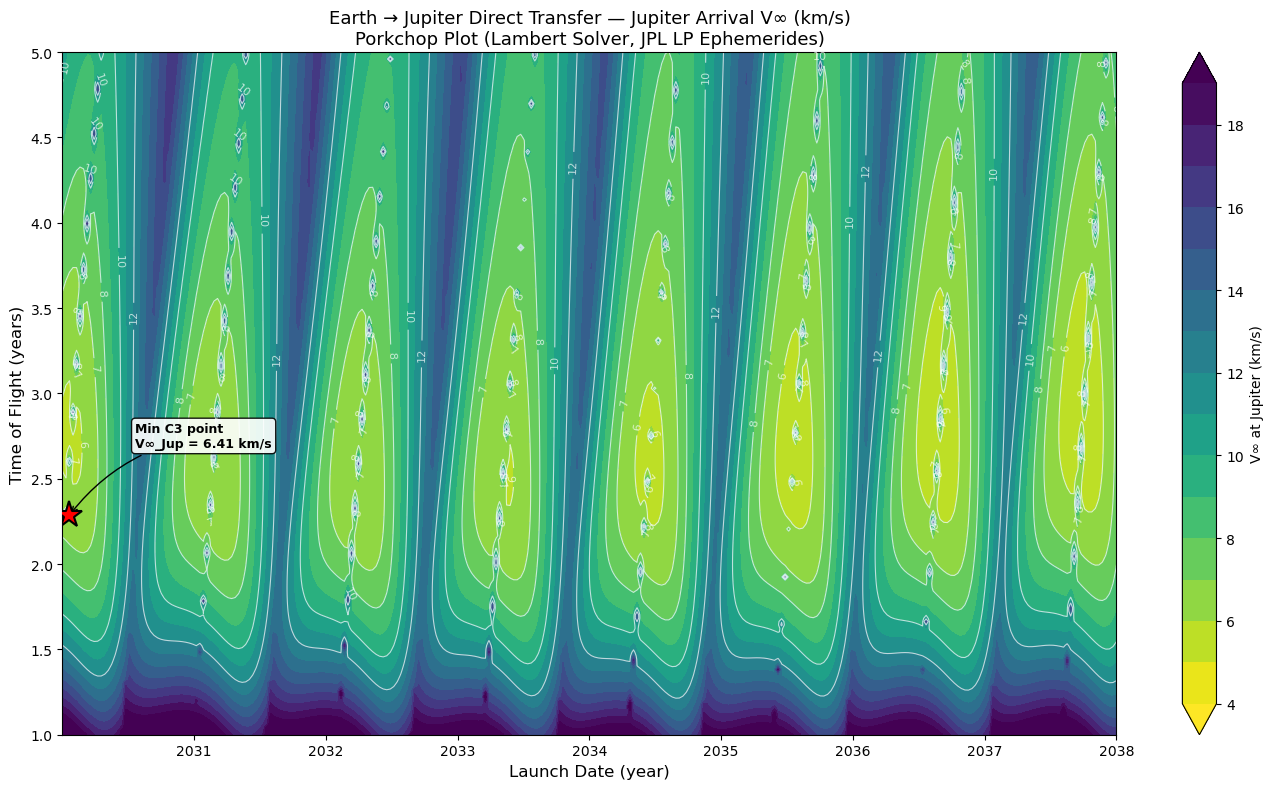

Saved: output/01_porkchop_vinf_jupiter.png


In [6]:
# %% Cell 6 — Arrival V∞ porkchop (secondary)
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

vinf_plot = np.clip(vinf_arr_grid, 0, 20)
levels_v = np.arange(4, 20, 1)
cf = ax.contourf(L, T, vinf_plot, levels=levels_v, cmap='viridis_r', extend='both')
cs = ax.contour(L, T, vinf_plot, levels=[5, 6, 7, 8, 10, 12], colors='w', 
                linewidths=0.8, alpha=0.7)
ax.clabel(cs, fmt='%.0f', fontsize=8)
cbar = plt.colorbar(cf, ax=ax, label='V∞ at Jupiter (km/s)')

# Mark same best-C3 point for reference
ax.plot(best_launch_yr, best_tof_yr, 'r*', markersize=20, markeredgecolor='k',
        markeredgewidth=1.5, zorder=10)
ax.annotate(f'Min C3 point\nV∞_Jup = {best_vinf_arr:.2f} km/s',
            xy=(best_launch_yr, best_tof_yr),
            xytext=(best_launch_yr + 0.5, best_tof_yr + 0.4),
            fontsize=9, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))

ax.set_xlabel('Launch Date (year)', fontsize=12)
ax.set_ylabel('Time of Flight (years)', fontsize=12)
ax.set_title('Earth → Jupiter Direct Transfer — Jupiter Arrival V∞ (km/s)\n'
             'Porkchop Plot (Lambert Solver, JPL LP Ephemerides)', fontsize=13)
ax.set_xlim(launch_years[0], launch_years[-1])
ax.set_ylim(tof_years[0], tof_years[-1])

plt.tight_layout()
plt.savefig('output/01_porkchop_vinf_jupiter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: output/01_porkchop_vinf_jupiter.png")

In [7]:
# %% Cell 7 — Summary statistics
print("=" * 55)
print("  DIRECT TRANSFER SUMMARY")
print("=" * 55)
print()
print(f"  Grid: {n_launch} x {n_tof} = {n_launch*n_tof:,} points")
print(f"  Valid solutions: {np.sum(valid):,}")
print(f"  Failed: {np.sum(~valid):,}")
print()
print(f"  C3 range:  {np.nanmin(C3_grid):.1f} — {np.nanpercentile(C3_grid, 95):.1f} km²/s²")
print(f"  Best C3:   {best_c3:.2f} km²/s²")
print(f"  V∞_dep:    {best_vinf_dep:.3f} km/s")
print(f"  V∞_arr:    {best_vinf_arr:.3f} km/s")
print(f"  ΔV (LEO):  {dv_from_leo:.3f} km/s")
print()
print(f"  Solutions with C3 < 100 km²/s²:  {np.sum(C3_grid < 100):,}")
print(f"  Solutions with C3 < 80 km²/s²:   {np.sum(C3_grid < 80):,}")
print(f"  Solutions with C3 < 60 km²/s²:   {np.sum(C3_grid < 60):,}")
print()
print("  CONCLUSION: No direct transfer achieves C3 < 60 km²/s².")
print("  Gravity assists are required to reduce departure energy.")
print("=" * 55)

  DIRECT TRANSFER SUMMARY

  Grid: 300 x 200 = 60,000 points
  Valid solutions: 60,000
  Failed: 0

  C3 range:  76.7 — 2157.5 km²/s²
  Best C3:   76.73 km²/s²
  V∞_dep:    8.760 km/s
  V∞_arr:    6.406 km/s
  ΔV (LEO):  6.285 km/s

  Solutions with C3 < 100 km²/s²:  3,530
  Solutions with C3 < 80 km²/s²:   25
  Solutions with C3 < 60 km²/s²:   0

  CONCLUSION: No direct transfer achieves C3 < 60 km²/s².
  Gravity assists are required to reduce departure energy.
